In [1]:
pip install pandas numpy matplotlib statsmodels openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


✅ داده با موفقیت بارگذاری شد: 360 نمونه ۱ دقیقه‌ای.

--- مقادیر خودهمبستگی (ACF) ---
Lag 01: 0.8493 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 02: 0.7662 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 03: 0.7317 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 04: 0.7184 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 05: 0.6992 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 06: 0.6634 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 07: 0.6375 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 08: 0.6124 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 09: 0.5721 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)
Lag 10: 0.5255 (آستانه: ±0.1054) -> ⚠️ معنادار (نقض استقلال)

--- نتایج نمودار شوهارت کلاسیک ---
میانگین: 9.4528 | انحراف معیار خام: 0.1718
حدود: [8.9375, 9.9682]
تعداد کل آلارم‌های اولیه: 1 از 360 نقطه (0.28%)

--- نتایج پس از اصلاح با واریانس مؤثر ---
فاکتور تصحیح (CF): 14.5511 | انحراف معیار مؤثر: 0.6553
حدود اصلاح‌شده: [7.4870, 11.4186]
تعداد آلارم‌های باقی‌ما

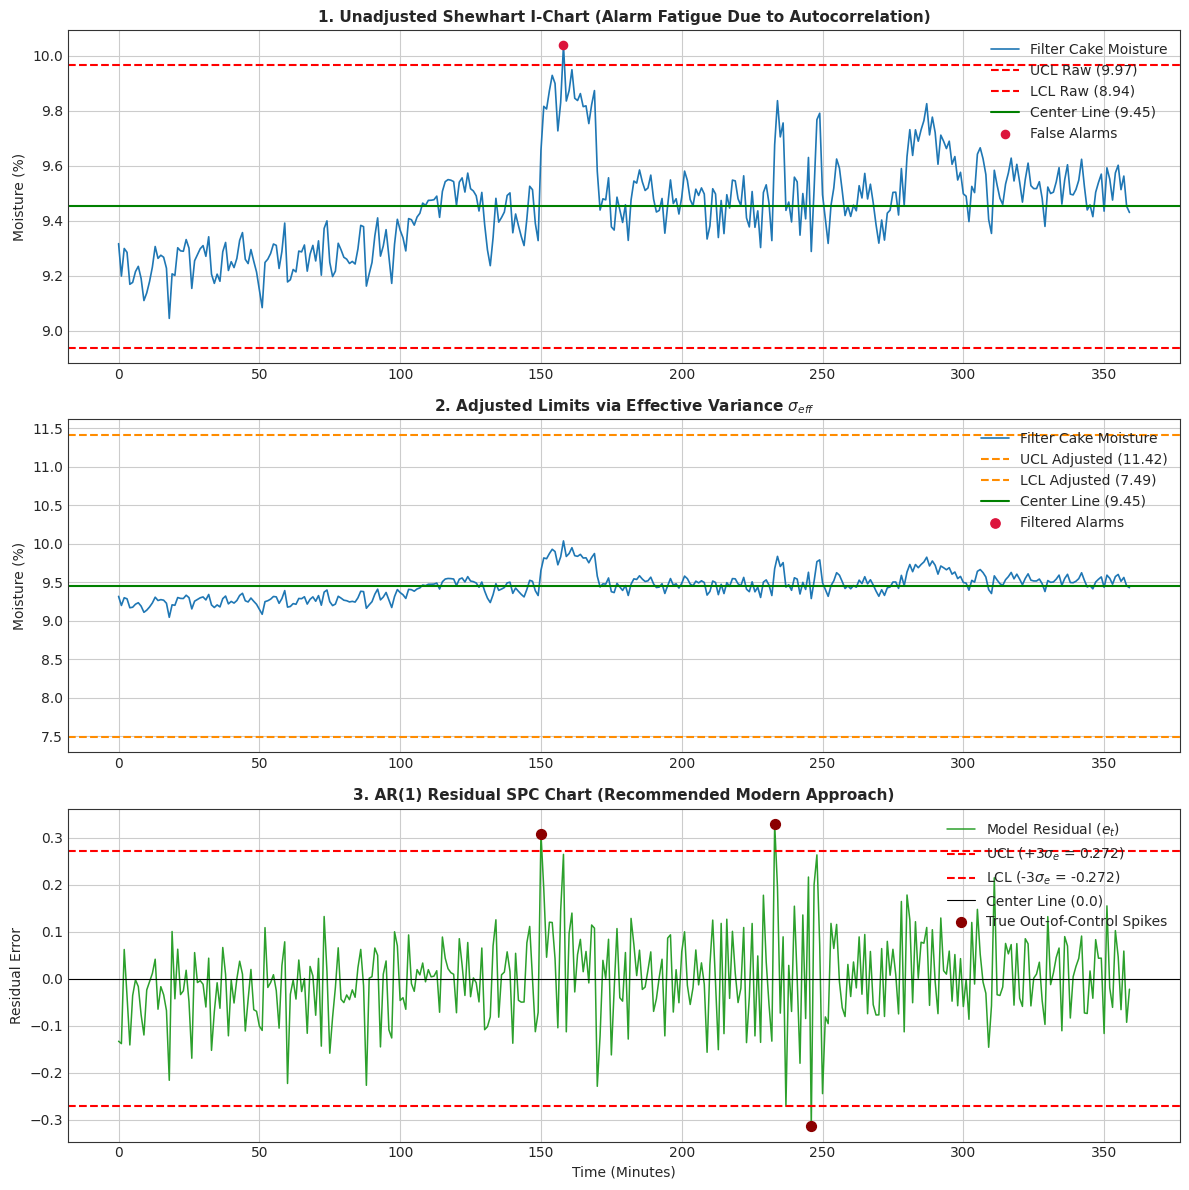

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf

# تنظیمات ظاهری نمودارها
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# ==============================================================================
# گام ۱: بارگذاری داده (Load Data)
# ==============================================================================
file_path = "CH06_SPC_autocorr_training_data.xlsx"
df = pd.read_excel(file_path, sheet_name="aggregated_1min")

# پاکسازی سطرهای خالی احتمالی
df = df.dropna(subset=["FilterCakeMoisture_Mean"]).reset_index(drop=True)
series = df["FilterCakeMoisture_Mean"]
n = len(series)

print(f"✅ داده با موفقیت بارگذاری شد: {n} نمونه ۱ دقیقه‌ای.")

# ==============================================================================
# گام ۲: محاسبه و تحلیل خودهمبستگی (ACF)
# ==============================================================================
nlags = 10
acf_values = acf(series, nlags=nlags, fft=True)
bartlett_limit = 2.0 / np.sqrt(n)

print("\n--- مقادیر خودهمبستگی (ACF) ---")
for k in range(1, nlags + 1):
    status = "⚠️ معنادار (نقض استقلال)" if abs(acf_values[k]) > bartlett_limit else "✅ نرمال"
    print(f"Lag {k:02d}: {acf_values[k]:.4f} (آستانه: ±{bartlett_limit:.4f}) -> {status}")

# ==============================================================================
# گام ۳: نمودار کنترل کلاسیک شوهارت (Unadjusted I-Chart)
# ==============================================================================
mu = series.mean()
sigma_raw = series.std(ddof=1)

ucl_raw = mu + 3 * sigma_raw
lcl_raw = mu - 3 * sigma_raw

alarms_raw = df[(series > ucl_raw) | (series < lcl_raw)]
print(f"\n--- نتایج نمودار شوهارت کلاسیک ---")
print(f"میانگین: {mu:.4f} | انحراف معیار خام: {sigma_raw:.4f}")
print(f"حدود: [{lcl_raw:.4f}, {ucl_raw:.4f}]")
print(f"تعداد کل آلارم‌های اولیه: {len(alarms_raw)} از {n} نقطه ({len(alarms_raw)/n*100:.2f}%)")

# ==============================================================================
# گام ۴: اصلاح حدود با واریانس مؤثر (Effective Variance Adjustment)
# ==============================================================================
# فرمول: CF = 1 + 2 * sum(rho_k)
correction_factor = 1.0 + 2.0 * np.sum(acf_values[1:nlags + 1])
sigma_eff = sigma_raw * np.sqrt(correction_factor)

ucl_adj = mu + 3 * sigma_eff
lcl_adj = mu - 3 * sigma_eff

alarms_adj = df[(series > ucl_adj) | (series < lcl_adj)]
print(f"\n--- نتایج پس از اصلاح با واریانس مؤثر ---")
print(f"فاکتور تصحیح (CF): {correction_factor:.4f} | انحراف معیار مؤثر: {sigma_eff:.4f}")
print(f"حدود اصلاح‌شده: [{lcl_adj:.4f}, {ucl_adj:.4f}]")
print(f"تعداد آلارم‌های باقی‌مانده: {len(alarms_adj)} از {n} نقطه ({len(alarms_adj)/n*100:.2f}%)")

# ==============================================================================
# گام ۵: برازش مدل AR(1) و نمودار کنترل باقیمانده‌ها (Residual SPC)
# ==============================================================================
# مدل ARIMA(1,0,0) روی سری رطوبت
model = ARIMA(series, order=(1, 0, 0))
model_fit = model.fit()

df["Residual"] = model_fit.resid
sigma_resid = df["Residual"].std(ddof=1)

ucl_resid = 3 * sigma_resid
lcl_resid = -3 * sigma_resid
cl_resid = 0.0

alarms_resid = df[(df["Residual"] > ucl_resid) | (df["Residual"] < lcl_resid)]
print(f"\n--- نتایج نمودار باقیمانده‌ها (AR(1) Residual SPC) ---")
print(f"ضریب AR(1) یا Phi: {model_fit.params.iloc[1]:.4f}")
print(f"انحراف معیار باقیمانده‌ها: {sigma_resid:.4f}")
print(f"حدود کنترل باقیمانده: [{lcl_resid:.4f}, {ucl_resid:.4f}]")
print(f"تعداد آلارم‌های واقعی شناسایی‌شده: {len(alarms_resid)}")

# ==============================================================================
# گام ۶: رسم داشبورد نمودارهای تحلیلی (Visual SPC Dashboard)
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

# 1. نمودار کلاسیک خام
axes[0].plot(series, color='#1f77b4', lw=1.2, label='Filter Cake Moisture')
axes[0].axhline(ucl_raw, color='red', linestyle='--', label=f'UCL Raw ({ucl_raw:.2f})')
axes[0].axhline(lcl_raw, color='red', linestyle='--', label=f'LCL Raw ({lcl_raw:.2f})')
axes[0].axhline(mu, color='green', linestyle='-', label=f'Center Line ({mu:.2f})')
axes[0].scatter(alarms_raw.index, alarms_raw["FilterCakeMoisture_Mean"], color='crimson', s=35, zorder=5, label='False Alarms')
axes[0].set_title("1. Unadjusted Shewhart I-Chart (Alarm Fatigue Due to Autocorrelation)", fontsize=11, fontweight='bold')
axes[0].legend(loc='upper right', framealpha=0.9)
axes[0].set_ylabel("Moisture (%)")

# 2. نمودار اصلاح‌شده با واریانس مؤثر
axes[1].plot(series, color='#1f77b4', lw=1.2, label='Filter Cake Moisture')
axes[1].axhline(ucl_adj, color='darkorange', linestyle='--', lw=1.5, label=f'UCL Adjusted ({ucl_adj:.2f})')
axes[1].axhline(lcl_adj, color='darkorange', linestyle='--', lw=1.5, label=f'LCL Adjusted ({lcl_adj:.2f})')
axes[1].axhline(mu, color='green', linestyle='-', label=f'Center Line ({mu:.2f})')
axes[1].scatter(alarms_adj.index, alarms_adj["FilterCakeMoisture_Mean"], color='crimson', s=45, zorder=5, label='Filtered Alarms')
axes[1].set_title("2. Adjusted Limits via Effective Variance $\\sigma_{eff}$", fontsize=11, fontweight='bold')
axes[1].legend(loc='upper right', framealpha=0.9)
axes[1].set_ylabel("Moisture (%)")

# 3. نمودار باقیمانده‌های مدل AR(1)
axes[2].plot(df["Residual"], color='#2ca02c', lw=1.1, label='Model Residual ($e_t$)')
axes[2].axhline(ucl_resid, color='red', linestyle='--', label=f'UCL (+3$\\sigma_e$ = {ucl_resid:.3f})')
axes[2].axhline(lcl_resid, color='red', linestyle='--', label=f'LCL (-3$\\sigma_e$ = {lcl_resid:.3f})')
axes[2].axhline(0, color='black', linestyle='-', lw=0.8, label='Center Line (0.0)')
axes[2].scatter(alarms_resid.index, alarms_resid["Residual"], color='darkred', s=50, zorder=5, label='True Out-of-Control Spikes')
axes[2].set_title("3. AR(1) Residual SPC Chart (Recommended Modern Approach)", fontsize=11, fontweight='bold')
axes[2].legend(loc='upper right', framealpha=0.9)
axes[2].set_xlabel("Time (Minutes)")
axes[2].set_ylabel("Residual Error")

plt.tight_layout()
plt.show()
